<a href="https://colab.research.google.com/github/Ism-ail11/Decision-Preserving-Channel-Skipping-for-INT8-NNs/blob/main/certified_tinyml_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Setup
import os, sys, io, time, math, copy, json, base64, hashlib, ctypes
import tempfile, pathlib, subprocess, shutil, importlib.util, platform
os.environ.setdefault('OMP_NUM_THREADS','4')
os.environ.setdefault('MKL_NUM_THREADS','4')
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG',':4096:8')
needed={'numpy':'numpy','pandas':'pandas','matplotlib':'matplotlib',
        'sklearn':'scikit-learn','torch':'torch'}
missing=[p for m,p in needed.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.check_call([sys.executable,'-m','pip','install','--quiet',*missing])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
get_ipython().run_line_magic('matplotlib','inline')
torch.set_num_threads(min(4,os.cpu_count() or 1))
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
torch.backends.cuda.matmul.allow_tf32=False
torch.backends.cudnn.allow_tf32=False
SEEDS=[17,29,43]
RETRAIN=False  # True retrains; False reproduces the bundled trained models.
EPOCHS={'digits':100,'har':60}
CALIBRATION_SAMPLES=256
TIMING_REPEATS=7
ROOT=pathlib.Path(tempfile.mkdtemp(prefix='certified_tinyml_'))
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.20,
                     'axes.spines.top':False,'axes.spines.right':False})
pd.set_option('display.max_columns',20)
print('Ready | seeds:',SEEDS,'| retrain:',RETRAIN)
display(pd.DataFrame([{'Python':platform.python_version(),'NumPy':np.__version__,
    'PyTorch':torch.__version__,'Training device':'CUDA' if torch.cuda.is_available() else 'CPU',
    'Timing device':'CPU / native C'}]))

Ready | seeds: [17, 29, 43] | retrain: False


,Python,NumPy,PyTorch,Training device,Timing device
0,3.12.14,2.3.5,2.14.1+cpu,CPU,CPU / native C


In [ ]:
#@title Embedded benchmark data
# UCI HAR: Reyes-Ortiz et al. (2013), doi:10.24432/C54S4K, CC BY 4.0.
# Digits: sklearn.datasets.load_digits, UCI optical recognition benchmark.
# HAR signals are rounded to 1/32 units; official test volunteers are preserved.
DATA_B64='...'
raw=base64.b64decode(DATA_B64)
assert hashlib.sha256(raw).hexdigest()=='5c298a6ac9900c43bbc7596128bc8259fcf58dcf15469f2c4c79dacde0cc7cb2'
with np.load(io.BytesIO(raw),allow_pickle=False) as archive:
    data={k:archive[k] for k in archive.files}
del DATA_B64,raw
assert not set(data['har_train_subject']) & set(data['har_valid_subject'])
assert not set(data['har_train_subject']) & set(data['har_test_subject'])
assert not set(data['har_valid_subject']) & set(data['har_test_subject'])
split_rows=[]
for task in ['digits','har']:
    for split in ['train','valid','test']:
        xx,yy=data[f'{task}_{split}_x'],data[f'{task}_{split}_y']
        split_rows.append({'Task':task,'Split':split,'Samples':len(xx),
                          'Input shape':str(xx.shape[1:]),'Classes':len(np.unique(yy))})
display(pd.DataFrame(split_rows))

,Task,Split,Samples,Input shape,Classes
0,digits,train,1077,"(1, 8, 8)",10
1,digits,valid,270,"(1, 8, 8)",10
2,digits,test,450,"(1, 8, 8)",10
3,har,train,6036,"(6, 128)",6
4,har,valid,1316,"(6, 128)",6
5,har,test,2947,"(6, 128)",6


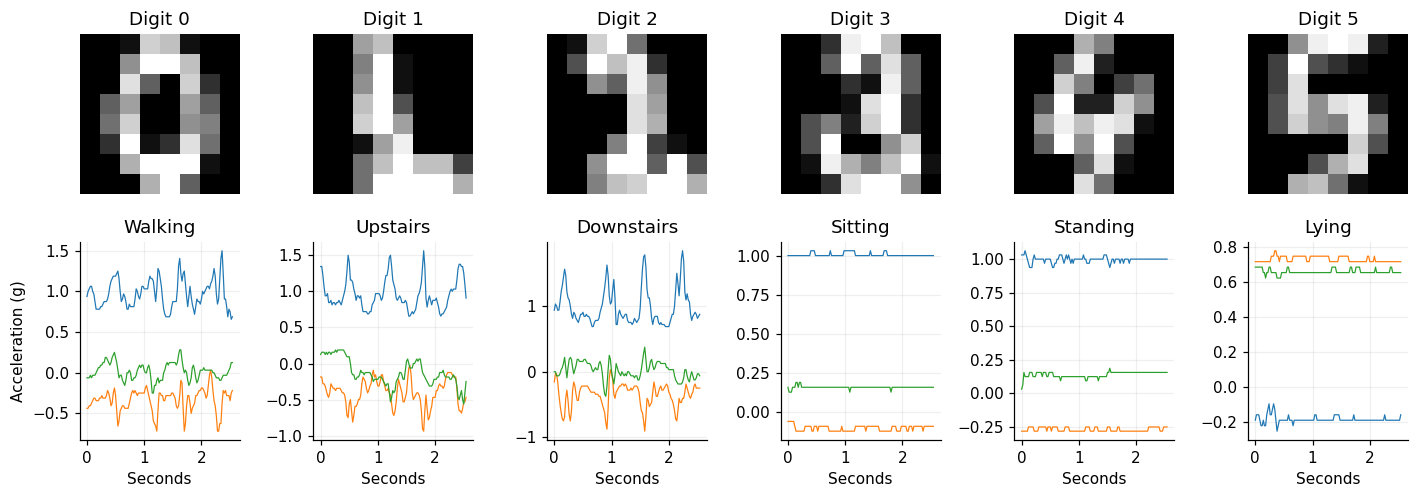

In [ ]:
#@title Benchmark samples
fig,ax=plt.subplots(2,6,figsize=(13,4.7))
for k in range(6):
    idx=np.flatnonzero(data['digits_test_y']==k)[0]
    ax[0,k].imshow(data['digits_test_x'][idx,0],cmap='gray',vmin=0,vmax=64)
    ax[0,k].set_title(f'Digit {k}');ax[0,k].axis('off')
    idx=np.flatnonzero(data['har_test_y']==k)[0]
    signal=data['har_test_x'][idx,:3].astype(float)/32
    ax[1,k].plot(np.arange(128)/50,signal.T,linewidth=.8)
    ax[1,k].set_title(['Walking','Upstairs','Downstairs','Sitting','Standing','Lying'][k])
    ax[1,k].set_xlabel('Seconds')
    if k==0: ax[1,k].set_ylabel('Acceleration (g)')
plt.tight_layout();plt.show()

In [ ]:
#@title Model and quantization code
def ste_quant(x, frac, lo, hi):
    scaled = x * (2.**frac)
    q = torch.floor(scaled + .5).clamp(lo,hi) / (2.**frac)
    return x + (q-x).detach()

def weight_frac(t):
    return int(np.clip(math.floor(math.log2(127./max(float(t.detach().abs().max()),1e-6))), 0,14))

def project_int8_weights(model):
    if not model.qat:return
    # Keep the low-rank layer representable before rounding to INT8.
    with torch.no_grad():
        for m,f in [(model.back,model.fracs[0]),(model.head,model.fracs[2])]:
            m.weight.clamp_(-127./2**f,127./2**f)
        limit=127./2**model.fracs[1]
        row_max=model.last.weight.flatten(1).abs().amax(1)
        scale=(row_max/limit).clamp_min(1.)
        model.last.left.div_(scale[:,None])

class LowRankPointwise(nn.Module):
    def __init__(self,task,inputs,outputs,rank=8):
        super().__init__()
        self.left=nn.Parameter(torch.empty(outputs,rank))
        self.right=nn.Parameter(torch.empty(rank,inputs))
        self.bias=nn.Parameter(torch.zeros(outputs))
        nn.init.kaiming_uniform_(self.left,a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.right,a=math.sqrt(5))
        self.dim=2 if task=='digits' else 1
        self.stride=(1,)*self.dim; self.padding=(0,)*self.dim
    @property
    def weight(self):
        return (self.left@self.right).reshape(len(self.bias),self.right.shape[1],*((1,)*self.dim))

class TinyNet(nn.Module):
    def __init__(self, task, channels=192):
        super().__init__()
        self.task, self.qat, self.fracs = task, False, None
        self.a_frac, self.h_frac = 6,7
        self.in_frac = 6 if task=='digits' else 5
        self.back = nn.Conv2d(1,32,5,padding=2) if task=='digits' else nn.Conv1d(6,32,17,stride=2,padding=8)
        self.last = LowRankPointwise(task,32,channels,rank=8)
        self.head = nn.Linear(4*channels,10 if task=='digits' else 6)
        self.channels = channels
        nn.init.constant_(self.last.bias,.15)
    def enable_qat(self):
        self.fracs = [weight_frac(m.weight) for m in [self.back,self.last,self.head]]
        self.qat = True
    def conv(self,x,m,frac,inf,outf):
        w,b=m.weight,m.bias
        if self.qat:
            w=ste_quant(w,frac,-127,127)
            b=ste_quant(b,frac+inf,-2147483647,2147483647)
        y = F.conv2d(x,w,b,m.stride,m.padding) if self.task=='digits' else F.conv1d(x,w,b,m.stride,m.padding)
        return ste_quant(y,outf,0,127) if self.qat else y.clamp(0,127./2**outf)
    def pool(self,x):
        return F.adaptive_avg_pool2d(x,(2,2)).flatten(1) if self.task=='digits' else F.adaptive_avg_pool1d(x,4).flatten(1)
    def forward(self,x, surrogate=False):
        f1,f2,fh = self.fracs if self.fracs else [0,0,0]
        a=self.conv(x,self.back,f1,self.in_frac,self.a_frac)
        h=self.conv(a,self.last,f2,self.a_frac,self.h_frac)
        w,b = self.head.weight,self.head.bias
        if self.qat:
            w=ste_quant(w,fh,-127,127)
            b=ste_quant(b,fh+self.h_frac+4,-2147483647,2147483647)
        logits=F.linear(self.pool(h),w,b)
        if not surrogate: return logits
        # The same weights are reused for the cheap pooled-input surrogate.
        pa=self.pool(a).reshape(len(a),32,4)
        ww=self.last.weight.flatten(1)
        bb=self.last.bias
        if self.qat:
            ww=ste_quant(ww,f2,-127,127)
            bb=ste_quant(bb,f2+self.a_frac,-2147483647,2147483647)
        ph=torch.einsum('oi,nir->nor',ww,pa)+bb[None,:,None]
        ph = ste_quant(ph,self.h_frac,0,127) if self.qat else ph.clamp(0,127./2**self.h_frac)
        return logits, F.linear(ph.flatten(1),w,b)

def train_model(task,data,seed=17,epochs=30):
    torch.manual_seed(seed); np.random.seed(seed)
    model=TinyNet(task)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model=model.to(device)
    scale=2.**model.in_frac
    xt=torch.from_numpy(data[f'{task}_train_x'].astype(np.float32)/scale)
    yt=torch.from_numpy(data[f'{task}_train_y'])
    xv=torch.from_numpy(data[f'{task}_valid_x'].astype(np.float32)/scale).to(device)
    yv=torch.from_numpy(data[f'{task}_valid_y']).to(device)
    generator=torch.Generator().manual_seed(seed)
    loader=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt,yt),batch_size=128,shuffle=True,generator=generator)
    opt=torch.optim.AdamW(model.parameters(),lr=.003,weight_decay=1e-4)
    history=[]; best=-1.; saved=None; best_fracs=None
    for epoch in range(epochs):
        if epoch==epochs//2:
            model.enable_qat(); best=-1.
            for group in opt.param_groups: group['lr']=.001
        model.train(); total=0.; correct=0
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(set_to_none=True)
            logits, cheap=model(x,surrogate=True)
            # Encourage useful pooled-input bounds without adding a classifier.
            loss=F.cross_entropy(logits,y)+.06*F.cross_entropy(cheap,y)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),3.); opt.step()
            project_int8_weights(model)
            total+=float(loss.detach())*len(x); correct+=int((logits.argmax(1)==y).sum())
        model.eval()
        with torch.no_grad():
            pred=model(xv).argmax(1); acc=float((pred==yv).float().mean())
        history.append({'task':task,'seed':seed,'epoch':epoch+1,'loss':total/len(xt),'train_accuracy':correct/len(xt),'valid_accuracy':acc,'qat':model.qat})
        if acc>best:
            best=acc; saved={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; best_fracs=copy.copy(model.fracs)
        if (epoch+1)%5==0: print(f'{task} seed={seed} epoch={epoch+1:02d} validation={acc:.3%}',flush=True)
    model.cpu(); model.load_state_dict(saved); model.qat=True; model.fracs=best_fracs
    return model,pd.DataFrame(history)

def quantize_model(model):
    fs=model.fracs
    def q(t,f,dtype):
        rounded=torch.floor(t.detach().cpu()*2.**f+.5).numpy().astype(np.float64)
        limit=127 if dtype==np.int8 else 2147483647
        return np.clip(rounded,-limit,limit).astype(dtype)
    w1=q(model.back.weight,fs[0],np.int8)
    # Match PyTorch's C-major kernel flattening.
    w1=np.ascontiguousarray(w1.reshape(32,-1))
    w2=np.ascontiguousarray(q(model.last.weight,fs[1],np.int8).reshape(model.channels,32))
    wh=np.ascontiguousarray(q(model.head.weight,fs[2],np.int8).reshape(model.head.out_features,model.channels,4))
    b1=q(model.back.bias,model.in_frac+fs[0],np.int32)
    b2=q(model.last.bias,model.a_frac+fs[1],np.int32)
    bh=q(model.head.bias,fs[2]+model.h_frac+4,np.int32)
    sh1=model.in_frac+fs[0]-model.a_frac
    sh2=model.a_frac+fs[1]-model.h_frac
    assert sh1>=0 and sh2>=0
    assert np.max(np.sum(np.abs(w1.astype(np.int64)),axis=1)*127+np.abs(b1.astype(np.int64)))<2**31
    assert np.max(np.sum(np.abs(w2.astype(np.int64)),axis=1)*127+np.abs(b2.astype(np.int64)))<2**31
    assert np.max(np.sum(np.abs(wh.astype(np.int64)),axis=(1,2))*16*127+np.abs(bh.astype(np.int64)))<2**31
    return {'task':model.task,'w1':w1,'w2':w2,'wh':wh,'b1':b1,'b2':b2,'bh':bh,'sh1':sh1,'sh2':sh2,'fracs':np.array(fs,dtype=np.int64)}

def patches(task,x):
    # Output layout is sample, pooling region, spatial position, kernel input.
    if task=='digits':
        padded=np.pad(x,((0,0),(0,0),(2,2),(2,2)))
        v=np.lib.stride_tricks.sliding_window_view(padded,(5,5),axis=(2,3))
        v=v.transpose(0,2,3,1,4,5).reshape(len(x),8,8,-1)
        v=v.reshape(len(x),2,4,2,4,-1).transpose(0,1,3,2,4,5).reshape(len(x),4,16,-1)
    else:
        padded=np.pad(x,((0,0),(0,0),(8,8)))
        v=np.lib.stride_tricks.sliding_window_view(padded,17,axis=2)[:,:,::2,:]
        v=v.transpose(0,2,1,3).reshape(len(x),4,16,-1)
    return np.ascontiguousarray(v,dtype=np.int8)

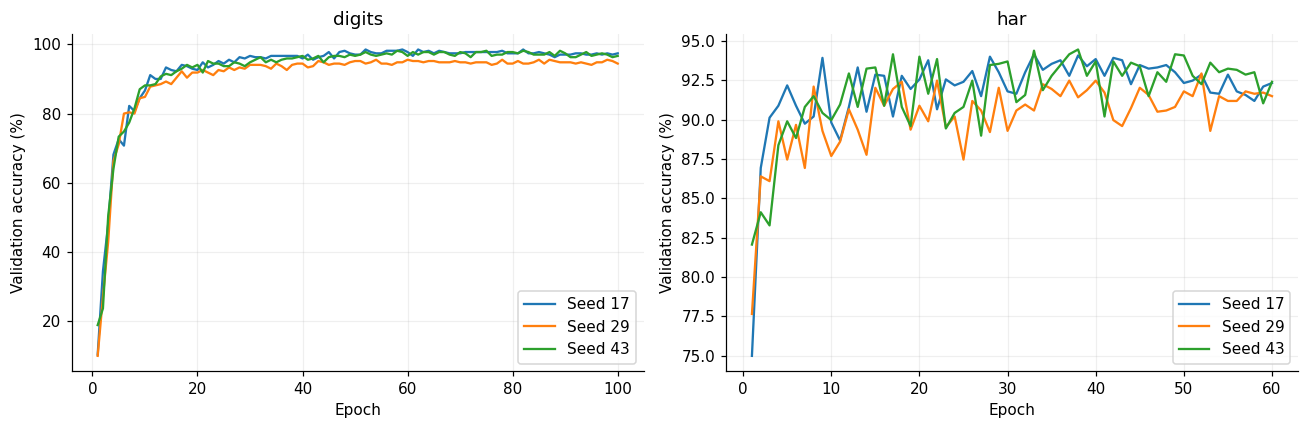

,task,seed,best_validation_accuracy
0,digits,17,0.985185
1,digits,29,0.955556
2,digits,43,0.981481
3,har,17,0.941489
4,har,29,0.929331
5,har,43,0.944529


In [ ]:
#@title Training and model checkpoints
import zipfile
MODEL_B64='...'
bundle=zipfile.ZipFile(io.BytesIO(base64.b64decode(MODEL_B64)))
models={};float_models={};histories=[]
for task in ['digits','har']:
    for seed in SEEDS:
        if RETRAIN:
            model,history=train_model(task,data,seed=seed,epochs=EPOCHS[task])
            q=quantize_model(model)
        else:
            with np.load(io.BytesIO(bundle.read(f'{task}_model_{seed}.npz')),allow_pickle=False) as a:
                q={k:a[k] for k in a.files}
            q['task']=task
            for key in ['sh1','sh2']:q[key]=int(q[key])
            history=pd.read_csv(io.BytesIO(bundle.read(f'{task}_history_{seed}.csv')))
            model=TinyNet(task)
            with np.load(io.BytesIO(bundle.read(f'{task}_state_{seed}.npz')),allow_pickle=False) as a:
                model.load_state_dict({k:torch.from_numpy(a[k]) for k in a.files if k!='fracs'})
                model.fracs=[int(v) for v in a['fracs']]
            model.qat=True
        for key,value in quantize_model(model).items():
            if key!='task':np.testing.assert_array_equal(value,q[key])
        models[(task,seed)]=q;float_models[(task,seed)]=model.eval();histories.append(history)
history=pd.concat(histories,ignore_index=True)
bundle.close();del MODEL_B64,bundle
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,task in zip(axes,['digits','har']):
    for seed in SEEDS:
        h=history[(history.task==task)&(history.seed==seed)]
        ax.plot(h.epoch,h.valid_accuracy*100,label=f'Seed {seed}')
    ax.set(title=task,xlabel='Epoch',ylabel='Validation accuracy (%)');ax.legend()
plt.tight_layout();plt.show()
display(history[history.qat].groupby(['task','seed'],as_index=False)
        .agg(best_validation_accuracy=('valid_accuracy','max')))

In [ ]:
#@title Certified integer kernels
C_SOURCE = '\n#include <stdint.h>\n#include <stdlib.h>\n#include <string.h>\n#define MAX_K 16\n#define MAX_J 256\n#define MAX_R 16\n#define MAX_I 128\n_Static_assert((-1 >> 1)==-1,"Arithmetic right shift is required.");\nstatic inline int64_t floor_div(int64_t a,int64_t b){int64_t q=a/b,r=a%b;return q-(r<0);}\nstatic inline int64_t mn(int64_t a,int64_t b){return a<b?a:b;}\nstatic inline int64_t mx(int64_t a,int64_t b){return a>b?a:b;}\nstatic inline int64_t pow_div(int64_t a,int shift){return a>>shift;}\nstatic inline int act(int64_t a,int shift){int64_t d=((int64_t)1)<<shift;int64_t q=pow_div(a+(shift?d/2:0),shift);return q<0?0:(q>127?127:(int)q);}\nstatic void lr_bounds(const int8_t*x,const int32_t*b,int shift,const int16_t*V,const int32_t*U,const int32_t*E,int rank,int R,int P,int I,int J,int64_t*lo,int64_t*hi,int64_t*cost){\n int32_t proj[R*P*rank];int amin[R*I],amax[R*I];\n const int32_t DEN=4096,off=shift?(((int32_t)1)<<shift)/2:0;\n for(int r=0;r<R;r++)for(int i=0;i<I;i++){\n  int a=127,z=0;for(int p=0;p<P;p++){int v=x[(r*P+p)*I+i];if(v<a)a=v;if(v>z)z=v;}\n  amin[r*I+i]=a;amax[r*I+i]=z;\n }\n for(int k=0;k<rank;k++)for(int t=0;t<R*P;t++){\n  int32_t z=0;for(int i=0;i<I;i++)z+=(int32_t)V[k*I+i]*x[t*I+i];proj[k*R*P+t]=z;\n }\n for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n  int32_t L=0,H=0;\n  for(int i=0;i<I;i++){int32_t e=E[j*I+i];L+=e*(e>=0?amin[r*I+i]:amax[r*I+i]);H+=e*(e>=0?amax[r*I+i]:amin[r*I+i]);}\n  int32_t proxy[P],sl=0,sh=0;\n  for(int p=0;p<P;p++)proxy[p]=(b[j]+off)*DEN;\n  for(int k=0;k<rank;k++)for(int p=0;p<P;p++)proxy[p]+=U[j*rank+k]*proj[k*R*P+r*P+p];\n  for(int p=0;p<P;p++){\n   int32_t ql=(proxy[p]+L)>>(shift+12),qh=(proxy[p]+H)>>(shift+12);\n   sl+=ql<0?0:(ql>127?127:ql);sh+=qh<0?0:(qh>127?127:qh);\n  }\n  lo[j*R+r]=sl;hi[j*R+r]=sh;\n }\n *cost+=(int64_t)R*P*rank*I+(int64_t)J*R*(2*I+P*rank);\n}\nvoid inspect_lr(const int8_t*x,const int32_t*b,int shift,const int16_t*V,const int32_t*U,const int32_t*E,int rank,int R,int P,int I,int J,int64_t*lo,int64_t*hi){int64_t cost=0;lr_bounds(x,b,shift,V,U,E,rank,R,P,I,J,lo,hi,&cost);}\nstatic void channel(const int8_t*x,const int8_t*w,int32_t b,int shift,int R,int P,int I,int64_t*out,int64_t*macs,const int64_t*lo,const int64_t*hi,int j){\n for(int r=0;r<R;r++){\n  if(lo && lo[j*R+r]==hi[j*R+r]){out[r]=lo[j*R+r];continue;}\n  int64_t s=0;\n  for(int p=0;p<P;p++){\n   int32_t a=b;const int8_t*t=x+(r*P+p)*I;\n   for(int i=0;i<I;i++)a+=(int32_t)t[i]*(int32_t)w[i];\n   s+=act(a,shift);\n  }\n  out[r]=s;*macs+=(int64_t)P*I;\n }\n}\nvoid backbone_batch(const int8_t*x,const int8_t*w,const int32_t*b,int shift,int N,int T,int D,int I,int8_t*out){\n for(int n=0;n<N;n++)for(int t=0;t<T;t++)for(int j=0;j<I;j++){\n  int32_t a=b[j];const int8_t*row=x+(n*T+t)*D;\n  for(int d=0;d<D;d++)a+=(int32_t)row[d]*(int32_t)w[j*D+d];\n  out[(n*T+t)*I+j]=(int8_t)act(a,shift);\n }\n}\nvoid dense_batch(const int8_t*x,const int8_t*w,const int32_t*b,int shift,const int8_t*head,const int32_t*hb,int N,int R,int P,int I,int J,int K,int32_t*pred,int64_t*logits,int64_t*stats){\n for(int n=0;n<N;n++){\n  int64_t score[MAX_K],h[MAX_R],macs=0;\n  for(int k=0;k<K;k++)score[k]=hb[k];\n  for(int j=0;j<J;j++){\n   channel(x+n*R*P*I,w+j*I,b[j],shift,R,P,I,h,&macs,NULL,NULL,j);\n   for(int k=0;k<K;k++)for(int r=0;r<R;r++)score[k]+=(int64_t)head[(k*J+j)*R+r]*h[r];\n  }\n  int win=0;for(int k=1;k<K;k++)if(score[k]>score[win])win=k;\n  pred[n]=win;for(int k=0;k<K;k++)logits[n*K+k]=score[k];\n  stats[n*6]=J;stats[n*6+1]=macs;stats[n*6+2]=0;stats[n*6+3]=(int64_t)K*J*R;stats[n*6+4]=0;stats[n*6+5]=0;\n }\n}\nvoid factorized_batch(const int8_t*x,const int32_t*b,int shift,const int8_t*head,const int32_t*hb,const int16_t*V,const int32_t*U,const int32_t*E,int rank,int exact,int N,int R,int P,int I,int J,int K,int32_t*pred,int64_t*logits,int64_t*stats){\n for(int n=0;n<N;n++){\n  const int8_t*xx=x+n*R*P*I;int32_t proj[rank*R*P];int64_t score[K];\n  int32_t off=shift?(((int32_t)1)<<shift)/2:0;\n  for(int k=0;k<rank;k++)for(int t=0;t<R*P;t++){\n   int32_t z=0;for(int i=0;i<I;i++)z+=(int32_t)V[k*I+i]*xx[t*I+i];proj[k*R*P+t]=z;\n  }\n  for(int k=0;k<K;k++)score[k]=hb[k];\n  for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n   int32_t proxy[P];int64_t h=0;\n   for(int p=0;p<P;p++)proxy[p]=(b[j]+off)*4096;\n   for(int k=0;k<rank;k++)for(int p=0;p<P;p++)proxy[p]+=U[j*rank+k]*proj[k*R*P+r*P+p];\n   if(exact)for(int p=0;p<P;p++)for(int i=0;i<I;i++)proxy[p]+=E[j*I+i]*xx[(r*P+p)*I+i];\n   for(int p=0;p<P;p++){int32_t a=proxy[p]>>(shift+12);h+=a<0?0:(a>127?127:a);}\n   for(int k=0;k<K;k++)score[k]+=(int64_t)head[(k*J+j)*R+r]*h;\n  }\n  int win=0;for(int k=1;k<K;k++)if(score[k]>score[win])win=k;\n  pred[n]=win;for(int k=0;k<K;k++)logits[n*K+k]=score[k];\n  stats[n*6]=J;stats[n*6+1]=exact?(int64_t)R*P*I*J:0;\n  stats[n*6+2]=(int64_t)R*P*rank*(I+J);stats[n*6+3]=(int64_t)K*J*R;stats[n*6+4]=stats[n*6+5]=0;\n }\n}\nstatic void moment_bounds(int64_t L,int64_t U,int64_t S,int P,int shift,int64_t*lo,int64_t*hi){\n int64_t D=((int64_t)1)<<shift,T=127*D, lower,upper;\n if(U<=0){*lo=*hi=0;return;}\n if(L>=T){*lo=*hi=(int64_t)P*127;return;}\n if(L==U){*lo=*hi=(int64_t)P*mx(0,mn(127,floor_div(L,D)));return;}\n if(L>=0 && U<=T){lower=upper=S;}\n else if(L<0 && U<=T){lower=mx(0,S);upper=floor_div(U*(S-P*L),U-L);}\n else if(L>=0 && U>T){lower=P*L+floor_div((T-L)*(S-P*L),U-L);upper=mn(S,(int64_t)P*T);}\n else {lower=mx(0,floor_div(T*S,U));upper=mn((int64_t)P*T,floor_div(T*(S-P*L),T-L));}\n *lo=mx(0,floor_div(lower,D)-(P-1));*hi=mn((int64_t)P*127,floor_div(upper,D));\n}\nvoid adaptive_batch(const int8_t*x,const int8_t*w,const int32_t*b,int shift,const int8_t*head,const int32_t*hb,const int32_t*order,int mode,int pair,int group,int first,const int16_t*V,const int32_t*U,const int32_t*E,int rank,int N,int R,int P,int I,int J,int K,int32_t*pred,int64_t*stats){\n for(int n=0;n<N;n++){\n  const int8_t*xx=x+n*R*P*I;\n  int64_t lo[J*R],hi[J*R],h[R];\n  int64_t amin[R*I],amax[R*I],asum[R*I];\n  int64_t low[K],high[K],center[K],marg[K*K],score[K];\n  int64_t conv=0,bound=0,products=0,checks=0,resolved=0;int used=0,win=-1,cached=-1;\n  int64_t D=((int64_t)1)<<shift,offset=shift?D/2:0;\n  if(mode==3){lr_bounds(xx,b,shift,V,U,E,rank,R,P,I,J,lo,hi,&bound);for(int t=0;t<J*R;t++)if(lo[t]==hi[t])resolved++;}\n  if(mode==1 || mode==2)for(int r=0;r<R;r++)for(int i=0;i<I;i++){\n   int64_t a=127,z=0,s=0;\n   for(int p=0;p<P;p++){int v=xx[(r*P+p)*I+i];a=mn(a,v);z=mx(z,v);s+=v;}\n   amin[r*I+i]=a;amax[r*I+i]=z;asum[r*I+i]=s;\n  }\n  if(mode!=3)for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n   int idx=j*R+r;\n   if(!mode){lo[idx]=0;hi[idx]=(int64_t)P*127;continue;}\n   int64_t L=b[j]+offset,U=L,S=(int64_t)P*L;\n   for(int i=0;i<I;i++){\n    int v=w[j*I+i];int64_t a=amin[r*I+i],z=amax[r*I+i];\n    L+=v*(v>=0?a:z);U+=v*(v>=0?z:a);bound+=2;\n    if(mode==2){S+=v*asum[r*I+i];bound++;}\n   }\n   if(mode==2)moment_bounds(L,U,S,P,shift,&lo[idx],&hi[idx]);\n   else {lo[idx]=(int64_t)P*mx(0,mn(127,floor_div(L,D)));hi[idx]=(int64_t)P*mx(0,mn(127,floor_div(U,D)));}\n   if(lo[idx]==hi[idx])resolved++;\n  }\n  for(int k=0;k<K;k++){\n   low[k]=high[k]=score[k]=hb[k];center[k]=2*(int64_t)hb[k];\n   for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n    int idx=j*R+r;int v=head[(k*J+j)*R+r];\n    if(!pair){low[k]+=(int64_t)v*(v>=0?lo[idx]:hi[idx]);high[k]+=(int64_t)v*(v>=0?hi[idx]:lo[idx]);products+=2;}\n    else {center[k]+=(int64_t)v*(lo[idx]+hi[idx]);products++;}\n   }\n   if(!pair)center[k]=low[k]+high[k];\n  }\n  if(pair==1)for(int k=0;k<K;k++)for(int d=0;d<K;d++){\n   int64_t z=(int64_t)hb[k]-hb[d];\n   if(k!=d)for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n    int v=(int)head[(k*J+j)*R+r]-(int)head[(d*J+j)*R+r];\n    z+=(int64_t)v*(v>=0?lo[j*R+r]:hi[j*R+r]);products++;\n   }\n   marg[k*K+d]=z;\n  }\n  for(int step=0;step<=J;step++){\n   int check=(step>=first && (step==0 || step%group==0 || step==J));\n   if(check && step<J){\n    int c=0;for(int k=1;k<K;k++)if(center[k]>center[c])c=k;\n    if(pair==2 && c!=cached){\n     for(int d=0;d<K;d++)if(d!=c){\n      int64_t z=(int64_t)hb[c]-hb[d];\n      for(int j=0;j<J;j++)for(int r=0;r<R;r++){\n       int v=(int)head[(c*J+j)*R+r]-(int)head[(d*J+j)*R+r];\n       z+=(int64_t)v*(v>=0?lo[j*R+r]:hi[j*R+r]);products++;\n      }\n      marg[d]=z;\n     }\n     cached=c;\n    }\n    int ok=1;checks++;\n    for(int d=0;d<K;d++)if(d!=c){int64_t m=pair==2?marg[d]:(pair?marg[c*K+d]:low[c]-high[d]);if(m<0 || (m==0 && c>d)){ok=0;break;}}\n    if(ok){win=c;break;}\n    if(first<0){\n     for(int j=0;j<J;j++){\n      channel(xx,w+j*I,b[j],shift,R,P,I,h,&conv,lo,hi,j);used++;\n      for(int k=0;k<K;k++)for(int r=0;r<R;r++){score[k]+=(int64_t)head[(k*J+j)*R+r]*h[r];products++;}\n     }\n     break;\n    }\n   }\n   if(step==J)break;\n   int j=order[step];\n   channel(xx,w+j*I,b[j],shift,R,P,I,h,&conv,lo,hi,j);used++;\n   for(int k=0;k<K;k++){\n    for(int r=0;r<R;r++){\n     int idx=j*R+r;int v=head[(k*J+j)*R+r];\n     score[k]+=(int64_t)v*h[r];products++;\n     if(!pair){low[k]+=(int64_t)v*(h[r]-(v>=0?lo[idx]:hi[idx]));high[k]+=(int64_t)v*(h[r]-(v>=0?hi[idx]:lo[idx]));products+=2;}\n     else {center[k]+=(int64_t)v*(2*h[r]-lo[idx]-hi[idx]);products++;}\n    }\n    if(!pair)center[k]=low[k]+high[k];\n   }\n   if(pair==1)for(int k=0;k<K;k++)for(int d=0;d<K;d++)if(k!=d)for(int r=0;r<R;r++){\n    int v=(int)head[(k*J+j)*R+r]-(int)head[(d*J+j)*R+r];\n    marg[k*K+d]+=(int64_t)v*(h[r]-(v>=0?lo[j*R+r]:hi[j*R+r]));products++;\n   }\n   if(pair==2){\n    if(cached>=0)for(int d=0;d<K;d++)if(d!=cached)for(int r=0;r<R;r++){\n     int v=(int)head[(cached*J+j)*R+r]-(int)head[(d*J+j)*R+r];\n     marg[d]+=(int64_t)v*(h[r]-(v>=0?lo[j*R+r]:hi[j*R+r]));products++;\n    }\n    for(int r=0;r<R;r++)lo[j*R+r]=hi[j*R+r]=h[r];\n   }\n  }\n  if(win<0){win=0;for(int k=1;k<K;k++)if(score[k]>score[win])win=k;}\n  pred[n]=win;stats[n*6]=used;stats[n*6+1]=conv;stats[n*6+2]=bound;stats[n*6+3]=products;stats[n*6+4]=checks;stats[n*6+5]=resolved;\n }\n}\nvoid inspect_bounds(const int8_t*x,const int8_t*w,const int32_t*b,int shift,int R,int P,int I,int J,int mode,int64_t*outlo,int64_t*outhi,int64_t*actual){\n int64_t amin[MAX_R*MAX_I],amax[MAX_R*MAX_I],asum[MAX_R*MAX_I],h[MAX_R],mac=0;\n int64_t D=((int64_t)1)<<shift,off=shift?D/2:0;\n for(int r=0;r<R;r++)for(int i=0;i<I;i++){\n  int64_t a=127,z=0,s=0;for(int p=0;p<P;p++){int v=x[(r*P+p)*I+i];a=mn(a,v);z=mx(z,v);s+=v;}\n  amin[r*I+i]=a;amax[r*I+i]=z;asum[r*I+i]=s;\n }\n for(int j=0;j<J;j++){\n  channel(x,w+j*I,b[j],shift,R,P,I,h,&mac,NULL,NULL,j);\n  for(int r=0;r<R;r++){\n   int64_t L=b[j]+off,U=L,S=(int64_t)P*L;\n   for(int i=0;i<I;i++){int v=w[j*I+i];int64_t a=amin[r*I+i],z=amax[r*I+i];L+=v*(v>=0?a:z);U+=v*(v>=0?z:a);S+=v*asum[r*I+i];}\n   int idx=j*R+r;actual[idx]=h[r];\n   if(!mode){outlo[idx]=0;outhi[idx]=(int64_t)P*127;}\n   else if(mode==1){outlo[idx]=(int64_t)P*mx(0,mn(127,floor_div(L,D)));outhi[idx]=(int64_t)P*mx(0,mn(127,floor_div(U,D)));}\n   else moment_bounds(L,U,S,P,shift,&outlo[idx],&outhi[idx]);\n  }\n }\n}\n'

def build_native():
    source=ROOT/'certified_kernels.c'; libpath=ROOT/'certified_kernels.so'
    source.write_text(C_SOURCE)
    subprocess.run(['gcc','-O3','-std=c11','-shared','-fPIC','-march=native',str(source),'-o',str(libpath)],check=True,capture_output=True)
    return ctypes.CDLL(str(libpath))

def ptr(a): return a.ctypes.data_as(ctypes.c_void_p)

def back_features(lib,q,p):
    N,R,P,D=p.shape; I=q['w1'].shape[0]
    out=np.empty((N,R,P,I),dtype=np.int8)
    lib.backbone_batch(ptr(p),ptr(q['w1']),ptr(q['b1']),q['sh1'],N,R*P,D,I,ptr(out))
    return out

def full(lib,q,x):
    N,R,P,I=x.shape; J=q['w2'].shape[0]; K=len(q['bh'])
    pred=np.empty(N,np.int32); scores=np.empty((N,K),np.int64); stats=np.empty((N,6),np.int64)
    lib.dense_batch(ptr(x),ptr(q['w2']),ptr(q['b2']),q['sh2'],ptr(q['wh']),ptr(q['bh']),N,R,P,I,J,K,ptr(pred),ptr(scores),ptr(stats))
    return pred,scores,stats

def factorized(lib,q,x,exact=True,rank=8):
    N,R,P,I=x.shape; J=q['w2'].shape[0]; K=len(q['bh']);lr=q['lr'][rank]
    pred=np.empty(N,np.int32);scores=np.empty((N,K),np.int64);stats=np.empty((N,6),np.int64)
    lib.factorized_batch(ptr(x),ptr(q['b2']),q['sh2'],ptr(q['wh']),ptr(q['bh']),
        ptr(lr['v']),ptr(lr['u']),ptr(lr['e']),rank,int(exact),N,R,P,I,J,K,ptr(pred),ptr(scores),ptr(stats))
    return pred,scores,stats

def adaptive(lib,q,x,cfg):
    N,R,P,I=x.shape; J=q['w2'].shape[0]; K=len(q['bh'])
    pred=np.empty(N,np.int32);stats=np.empty((N,6),np.int64)
    rank=cfg.get('rank',4); lr=q['lr'][rank]
    lib.adaptive_batch(ptr(x),ptr(q['w2']),ptr(q['b2']),q['sh2'],ptr(q['wh']),ptr(q['bh']),ptr(cfg['order']),cfg['mode'],cfg['pair'],cfg['group'],cfg.get('first',0),ptr(lr['v']),ptr(lr['u']),ptr(lr['e']),rank,N,R,P,I,J,K,ptr(pred),ptr(stats))
    return pred,stats

def bounds(lib,q,x,mode=2,rank=4):
    R,P,I=x.shape; J=q['w2'].shape[0]
    out=[np.empty((J,R),np.int64) for _ in range(3)]
    lib.inspect_bounds(ptr(x),ptr(q['w2']),ptr(q['b2']),q['sh2'],R,P,I,J,min(mode,2),*[ptr(a) for a in out])
    if mode==3:
        lr=q['lr'][rank]
        lib.inspect_lr(ptr(x),ptr(q['b2']),q['sh2'],ptr(lr['v']),ptr(lr['u']),ptr(lr['e']),rank,R,P,I,J,ptr(out[0]),ptr(out[1]))
    return out

def orders(lib,q,x):
    J=q['w2'].shape[0]
    identity=np.arange(J,dtype=np.int32)
    contrast=np.ptp(q['wh'].astype(np.int64),axis=0).sum(axis=1)
    basic=np.argsort(-contrast,kind='stable').astype(np.int32)
    _,scores,_=full(lib,q,x)
    top=np.argsort(scores,axis=1)[:,-2:]
    importance=np.zeros(J)
    for n in range(min(192,len(x))):
        _,_,h=bounds(lib,q,x[n])
        d=q['wh'][top[n,1]].astype(np.int64)-q['wh'][top[n,0]].astype(np.int64)
        importance+=np.maximum((d*h).sum(axis=1),0)
    learned=np.argsort(-importance,kind='stable').astype(np.int32)
    return {'identity':identity,'contrast':basic,'calibrated':learned}

def add_lowrank(q,ranks=(2,4,8)):
    w=q['w2'].astype(np.float64)
    u,s,v=np.linalg.svd(w,full_matrices=False)
    q['lr']={}
    for rank in ranks:
        actual=min(rank,len(s))
        left=np.zeros((len(w),rank),np.int32); right=np.zeros((rank,w.shape[1]),np.int16)
        left[:,:actual]=np.floor(u[:,:actual]*s[:actual]*16+.5).astype(np.int32)
        right[:actual]=np.floor(v[:actual]*256+.5).astype(np.int16)
        residual=q['w2'].astype(np.int64)*4096-left.astype(np.int64)@right.astype(np.int64)
        assert np.array_equal(left.astype(np.int64)@right.astype(np.int64)+residual,q['w2'].astype(np.int64)*4096)
        off=2**int(q['sh2'])//2 if q['sh2'] else 0
        bound=(np.abs(left.astype(np.int64))@(np.abs(right.astype(np.int64)).sum(1)*127)+np.abs(residual).sum(1)*127+(np.abs(q['b2'].astype(np.int64))+off)*4096).max()
        assert bound<2**31,'Low-rank arithmetic exceeds int32 range.'
        q['lr'][rank]={'u':np.ascontiguousarray(left),'v':np.ascontiguousarray(right),'e':np.ascontiguousarray(residual,dtype=np.int32)}
    return q

def benchmark(fun,repeats=9):
    fun(); times=[]
    for _ in range(repeats):
        start=time.perf_counter_ns();fun();times.append((time.perf_counter_ns()-start)/1e6)
    return float(np.median(times)),np.array(times)

def benchmark_suite(functions,repeats=7,seed=9001):
    for fn in functions.values():fn()
    rng=np.random.default_rng(seed);names=list(functions)
    elapsed={name:[] for name in names}
    for _ in range(repeats):
        for index in rng.permutation(len(names)):
            name=names[index];start=time.perf_counter_ns();functions[name]()
            elapsed[name].append((time.perf_counter_ns()-start)/1e6)
    return {k:np.array(v) for k,v in elapsed.items()}

def tune(lib,q,x):
    os_=orders(lib,q,x)
    basepred,_,bs=full(lib,q,x)
    basecost=(bs[:,1]+bs[:,3]).mean()
    rows=[]; candidates=[]
    for mode,pair,rank in [(0,0,4),(1,1,4),(2,0,4),(2,1,4),(3,0,2),(3,0,4),(3,0,8),(3,1,4),(3,2,4),(3,2,8)]:
        for name,order in os_.items():
            for group,first in [(4,0),(8,0),(16,0),(32,0),(32,-1)]:
                if first<0 and name!='identity':continue
                cfg={'mode':mode,'pair':pair,'group':group,'first':first,'rank':rank,'order':order,'order_name':name}
                pred,st=adaptive(lib,q,x,cfg)
                assert np.array_equal(pred,basepred)
                cost=(st[:,1]+st[:,2]+st[:,3]).mean()
                rows.append({'mode':mode,'pair':pair,'rank':rank,'order':name,'group':group,'first':first,'product_reduction_pct':100*(1-cost/basecost),'channel_skip_pct':100*(1-st[:,0].mean()/len(order))})
                candidates.append((cost,cfg))
    candidates.sort(key=lambda c:c[0])
    # Measure CPU time for every strategy family; product counts are not latency.
    representatives={}
    for cost,cfg in candidates:
        key=(cfg['mode'],cfg['pair'],cfg['rank'],cfg['first'])
        if key not in representatives:representatives[key]=(cost,cfg)
    shortlist=list(representatives.values())
    times=benchmark_suite({i:lambda cfg=cfg:adaptive(lib,q,x,cfg)
                          for i,(_,cfg) in enumerate(shortlist)},repeats=7)
    selected=shortlist[min(times,key=lambda i:np.median(times[i]))][1]
    return selected,pd.DataFrame(rows),os_

lib=build_native()
for q in models.values(): add_lowrank(q)
print('Native integer kernels compiled; all low-rank residual identities verified.')

Native integer kernels compiled; all low-rank residual identities verified.


In [ ]:
#@title Independent correctness checks
import numpy as np

def numpy_reference(q,x):
    a=np.einsum('nrpi,ji->nrpj',x.astype(np.int64),q['w2'].astype(np.int64))+q['b2'][None,None,None,:]
    d=2**int(q['sh2']); off=d//2 if q['sh2'] else 0
    h=np.clip((a+off)//d,0,127).sum(axis=2).transpose(0,2,1)
    logits=np.einsum('njr,kjr->nk',h,q['wh'].astype(np.int64))+q['bh'][None]
    return np.argmax(logits,axis=1).astype(np.int32),logits,h

def run_checks(lib,full,adaptive,bounds,add_lowrank,factorized):
    rng=np.random.default_rng(84021)
    samples=0; bounds_count=0; decisions=0;factor_checks=0
    for trial in range(100):
        N,R,P,I,J,K=5,2,5,4,8,3
        x=rng.integers(0,128,(N,R,P,I),dtype=np.int8)
        if trial%5==0: x[:]=0
        if trial%5==1: x[:]=127
        if trial%5==2: x[:]=x[:,:,0:1,:]
        q={'w2':rng.integers(-127,128,(J,I),dtype=np.int16).astype(np.int8),
           'b2':rng.integers(-20000,20001,J,dtype=np.int32),
           'wh':rng.integers(-127,128,(K,J,R),dtype=np.int16).astype(np.int8),
           'bh':rng.integers(-10000,10001,K,dtype=np.int32),'sh2':trial%12}
        if trial%10==0: q['wh'][:]=0; q['bh'][:]=0
        if trial%10==1: q['wh'][:]=0; q['bh'][:]=np.array([0,1,1])
        if trial%10==2: q['b2'][:]=100000
        if trial%10==3: q['b2'][:]=-100000
        add_lowrank(q)
        rp,rl,rh=numpy_reference(q,x)
        cp,cl,_=full(lib,q,x)
        np.testing.assert_array_equal(cp,rp);np.testing.assert_array_equal(cl,rl)
        samples+=N
        for rank in [2,4,8]:
            fp,fl,_=factorized(lib,q,x,exact=True,rank=rank)
            np.testing.assert_array_equal(fp,rp);np.testing.assert_array_equal(fl,rl)
            lr=q['lr'][rank]
            projection=np.einsum('nrpi,ki->nrpk',x.astype(np.int64),lr['v'].astype(np.int64))
            proxy=np.einsum('nrpk,jk->nrpj',projection,lr['u'].astype(np.int64))
            d=2**int(q['sh2']);off=d//2 if q['sh2'] else 0
            proxy+=(q['b2'].astype(np.int64)+off)[None,None,None,:]*4096
            h=np.clip(proxy//(d*4096),0,127).sum(axis=2).transpose(0,2,1)
            logits=np.einsum('njr,kjr->nk',h,q['wh'].astype(np.int64))+q['bh'][None]
            ap,al,_=factorized(lib,q,x,exact=False,rank=rank)
            np.testing.assert_array_equal(al,logits)
            np.testing.assert_array_equal(ap,logits.argmax(1))
            factor_checks+=2*N
        for mode in [0,1,2,3]:
            for rank in ([2,4,8] if mode==3 else [4]):
                for n in range(N):
                    lo,hi,actual=bounds(lib,q,x[n],mode,rank)
                    np.testing.assert_array_equal(actual,rh[n])
                    assert np.all(lo<=actual) and np.all(actual<=hi)
                    assert np.all(lo<=hi)
                    bounds_count+=lo.size
                for pair in [0,1,2]:
                    for first in [trial%3,-1]:
                        cfg={'mode':mode,'rank':rank,'pair':pair,'group':1+trial%5,'first':first,'order':rng.permutation(J).astype(np.int32)}
                        pred,stats=adaptive(lib,q,x,cfg)
                        np.testing.assert_array_equal(pred,rp)
                        assert np.all((stats[:,0]>=0)&(stats[:,0]<=J))
                        decisions+=N
    return {'Independent integer references':samples,
            'Activation bounds checked':bounds_count,
            'Factorized baseline predictions checked':factor_checks,
            'Certified predictions checked':decisions,
            'Failed checks':0}


checks=run_checks(lib,full,adaptive,bounds,add_lowrank,factorized)
display(pd.DataFrame([{'Check':k,'Count':v,'Status':'PASS'} for k,v in checks.items()]))

,Check,Count,Status
0,Independent integer references,500,PASS
1,Activation bounds checked,48000,PASS
2,Factorized baseline predictions checked,3000,PASS
3,Certified predictions checked,18000,PASS
4,Failed checks,0,PASS


In [ ]:
#@title Integer features and memory
features={};input_patches={};memory_rows=[];export_rows=[]
for (task,seed),q in models.items():
    for split in ['valid','test']:
        key=(task,split)
        if key not in input_patches:
            input_patches[key]=patches(task,data[f'{task}_{split}_x'])
        features[(task,seed,split)]=back_features(lib,q,input_patches[key])
    model=float_models[(task,seed)];xx=data[f'{task}_valid_x']
    with torch.no_grad():
        train_logits=model(torch.from_numpy(xx.astype(np.float32)/2**model.in_frac)).numpy()
    ref,integer_logits,_=full(lib,q,features[(task,seed,'valid')])
    scaled=np.rint(train_logits*2**(model.fracs[2]+model.h_frac+4)).astype(np.int64)
    np.testing.assert_array_equal(scaled,integer_logits)
    np.testing.assert_array_equal(train_logits.argmax(1),ref)
    export_rows.append({'Task':task,'Seed':seed,'Validation samples checked':len(xx),
                        'Logits matching training model (%)':100.0,'Prediction mismatches':0})
    J,I=q['w2'].shape;K=len(q['bh']);R,P=4,16
    base_bytes=sum(q[k].nbytes for k in ['w1','w2','wh','b1','b2','bh'])
    lr_bytes=sum(a.nbytes for a in q['lr'][8].values())
    workspace=16*J*R+24*R*I+8*(K*K+4*K+R)+4*R*P*8+8*R*I+4*P
    memory_rows.append({'Task':task,'Seed':seed,'INT8 model bytes':base_bytes,
        'Rank-8 metadata bytes':lr_bytes,'Estimated certificate workspace bytes':workspace})
display(pd.DataFrame(memory_rows))
display(pd.DataFrame(export_rows))

,Task,Seed,INT8 model bytes,Rank-8 metadata bytes,Estimated certificate workspace bytes
0,digits,17,15560,31232,19648
1,digits,29,15560,31232,19648
2,digits,43,15560,31232,19648
3,har,17,14936,31232,19008
4,har,29,14936,31232,19008
5,har,43,14936,31232,19008


,Task,Seed,Validation samples checked,Logits matching training model (%),Prediction mismatches
0,digits,17,270,100.0,0
1,digits,29,270,100.0,0
2,digits,43,270,100.0,0
3,har,17,1316,100.0,0
4,har,29,1316,100.0,0
5,har,43,1316,100.0,0


In [ ]:
#@title Validation-only calibration
def method_call(lib,q,x,cfg):
    if cfg is None:out=full(lib,q,x)
    elif cfg.get('kind')=='factorized':
        out=factorized(lib,q,x,exact=cfg['exact'],rank=cfg['rank'])
    else:out=adaptive(lib,q,x,cfg)
    return out[0],out[-1]

def method_key(cfg):
    if cfg is None:return ('full',)
    if cfg.get('kind')=='factorized':return ('factorized',cfg['exact'],cfg['rank'])
    return ('certificate',cfg['mode'],cfg['pair'],cfg['rank'],cfg['group'],
            cfg.get('first',0),cfg['order'].tobytes())

configs={};calibrations=[];policies={};validation_orders={};static_configs={}
for (task,seed),q in models.items():
    x=features[(task,seed,'valid')]
    idx=np.random.default_rng(1729).choice(len(x),min(CALIBRATION_SAMPLES,len(x)),replace=False)
    calibration=np.ascontiguousarray(x[idx])
    cfg,table,oo=tune(lib,q,calibration)
    configs[(task,seed)]=cfg;validation_orders[(task,seed)]=oo
    static_options=[None]+[{'kind':'factorized','exact':True,'rank':r} for r in [2,4,8]]
    cal_calls={i:lambda sc=sc:method_call(lib,q,calibration,sc)
               for i,sc in enumerate(static_options)}
    cal_calls['certificate']=lambda:adaptive(lib,q,calibration,cfg)
    cal_times=benchmark_suite(cal_calls,repeats=7)
    static_times=[np.median(cal_times[i]) for i in range(len(static_options))]
    winner=int(np.argmin(static_times));sc=static_options[winner];tb=static_times[winner]
    static_configs[(task,seed)]=sc
    ta=np.median(cal_times['certificate'])
    use_certificate=ta<.97*tb
    policies[(task,seed)]=cfg if use_certificate else sc
    static_name='Dense INT8' if sc is None else f"Exact factorized rank {sc['rank']}"
    calibrations.append({'Task':task,'Seed':seed,'Bound mode':cfg['mode'],
        'Margin check':['Class intervals','All class pairs','Candidate pairs'][cfg['pair']],
        'Rank':cfg['rank'],'Group':cfg['group'],'Order':cfg['order_name'],
        'Fallback':'Direct dense' if cfg['first']<0 else 'Incremental',
        'Best exact static':static_name,'Validation speedup vs best static':tb/ta,
        'Auto CPU policy':'Certificate' if use_certificate else static_name})
display(pd.DataFrame(calibrations).round(3))

,Task,Seed,Bound mode,Margin check,Rank,Group,Order,Fallback,Best exact static,Validation speedup vs best static,Auto CPU policy
0,digits,17,3,Class intervals,8,4,calibrated,Incremental,Exact factorized rank 2,1.029,Exact factorized rank 2
1,digits,29,3,Class intervals,8,4,contrast,Incremental,Exact factorized rank 2,1.048,Certificate
2,digits,43,3,Class intervals,8,4,contrast,Incremental,Exact factorized rank 2,1.014,Exact factorized rank 2
3,har,17,3,Class intervals,8,4,contrast,Incremental,Exact factorized rank 2,1.264,Certificate
4,har,29,3,Class intervals,8,4,contrast,Incremental,Exact factorized rank 2,1.202,Certificate
5,har,43,3,Class intervals,8,4,contrast,Incremental,Exact factorized rank 2,1.226,Certificate


In [ ]:
#@title Complete test results
def paired_timings(functions,repeats=TIMING_REPEATS):
    return benchmark_suite(functions,repeats=repeats)

def variants(task,seed):
    q=models[(task,seed)];oo=validation_orders[(task,seed)]
    identity=oo['identity'];contrast=oo['contrast']
    common={'group':8,'first':0,'rank':8}
    return {
        'Full INT8':None,
        'Exact factorized + residual':{'kind':'factorized','exact':True,'rank':8},
        'Approximate rank-8':{'kind':'factorized','exact':False,'rank':8},
        'Best exact static':static_configs[(task,seed)],
        'Static certificate':dict(common,mode=0,pair=0,order=identity),
        'Input intervals + margins':dict(common,mode=1,pair=1,order=contrast),
        'Moment certificate':dict(common,mode=2,pair=0,order=contrast),
        'Moment + pair margins':dict(common,mode=2,pair=1,order=contrast),
        'Low-rank certificate':dict(common,mode=3,pair=0,order=contrast),
        'Candidate-only margins':dict(common,mode=3,pair=2,order=contrast),
        'Certificate + dense fallback':dict(common,mode=3,pair=2,order=contrast,first=-1),
        'Tuned certificate':configs[(task,seed)],
        'Auto CPU policy':policies[(task,seed)],
    }

results=[];predictions={};raw_stats={};timing_runs={}
# Tracked products include convolution, bound dot products, and classifier products.
# CPU timings also include checks, comparisons, and scalar bound arithmetic.
for (task,seed),q in models.items():
    x=features[(task,seed,'test')];y=data[f'{task}_test_y'];pp=input_patches[(task,'test')]
    ref,logits,base_stats=full(lib,q,x)
    reference_products=(base_stats[:,1]+base_stats[:,3]).mean()
    calls={};pipeline_calls={};per_method={};shared={};aliases={}
    for name,cfg in variants(task,seed).items():
        key=method_key(cfg)
        exact=not (cfg is not None and cfg.get('kind')=='factorized' and not cfg['exact'])
        if key in shared:
            alias=shared[key];pred,stats,_=per_method[alias]
        else:
            alias=name;shared[key]=name
            pred,stats=method_call(lib,q,x,cfg)
            calls[name]=lambda q=q,x=x,cfg=cfg:method_call(lib,q,x,cfg)
            pipeline_calls[name]=lambda q=q,pp=pp,cfg=cfg:method_call(lib,q,back_features(lib,q,pp),cfg)
        if exact:np.testing.assert_array_equal(pred,ref)
        aliases[name]=alias
        predictions[(task,seed,name)]=pred;raw_stats[(task,seed,name)]=stats
        per_method[name]=(pred,stats,exact)
    block_times=paired_timings(calls);cnn_times=paired_timings(pipeline_calls)
    block_times={name:block_times[aliases[name]] for name in per_method}
    cnn_times={name:cnn_times[aliases[name]] for name in per_method}
    timing_runs[(task,seed,'block')]=block_times;timing_runs[(task,seed,'cnn')]=cnn_times
    base_block=np.median(block_times['Full INT8']);base_cnn=np.median(cnn_times['Full INT8'])
    best_block=np.median(block_times['Best exact static']);best_cnn=np.median(cnn_times['Best exact static'])
    for name,(pred,stats,exact) in per_method.items():
        products=(stats[:,1]+stats[:,2]+stats[:,3]).mean()
        results.append({'Task':task,'Seed':seed,'Method':name,
            'Guaranteed exact':exact,'Accuracy (%)':100*accuracy_score(y,pred),
            'Macro F1':f1_score(y,pred,average='macro'),
            'Reference agreement (%)':100*np.mean(pred==ref),
            'Reference disagreements':int(np.sum(pred!=ref)),
            'Channels skipped (%)':100*(1-stats[:,0].mean()/q['w2'].shape[0]),
            'Convolution MAC reduction (%)':100*(1-stats[:,1].mean()/base_stats[:,1].mean()),
            'Tracked-product reduction (%)':100*(1-products/reference_products),
            'Zero-channel certificates (%)':100*np.mean(stats[:,0]==0),
            'Block CPU us/sample':1000*np.median(block_times[name])/len(x),
            'CNN CPU us/sample':1000*np.median(cnn_times[name])/len(x),
            'Block CPU speedup':base_block/np.median(block_times[name]),
            'CNN CPU speedup':base_cnn/np.median(cnn_times[name]),
            'Block speedup vs best static':best_block/np.median(block_times[name]),
            'CNN speedup vs best static':best_cnn/np.median(cnn_times[name])})
results=pd.DataFrame(results)
assert (results.loc[results['Guaranteed exact'],'Reference disagreements']==0).all()
display(results.round(3))

,Task,Seed,Method,Guaranteed exact,Accuracy (%),Macro F1,Reference agreement (%),Reference disagreements,Channels skipped (%),Convolution MAC reduction (%),Tracked-product reduction (%),Zero-channel certificates (%),Block CPU us/sample,CNN CPU us/sample,Block CPU speedup,CNN CPU speedup,Block speedup vs best static,CNN speedup vs best static
0,digits,17,Full INT8,True,95.556,0.955,100.000,0,0.000,0.000,0.000,0.000,99.351,130.451,1.000,1.000,0.621,0.736
1,digits,17,Exact factorized + residual,True,95.556,0.955,100.000,0,0.000,0.000,-28.608,0.000,80.735,112.653,1.231,1.158,0.764,0.852
2,digits,17,Approximate rank-8,False,95.333,0.953,99.778,1,0.000,100.000,69.476,0.000,46.280,80.651,2.147,1.617,1.332,1.190
3,digits,17,Best exact static,True,95.556,0.955,100.000,0,0.000,0.000,-7.152,0.000,61.664,96.014,1.611,1.359,1.000,1.000
4,digits,17,Static certificate,True,95.556,0.955,100.000,0,4.898,4.898,-2.577,0.000,120.071,153.747,0.827,0.848,0.514,0.624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,har,43,Low-rank certificate,True,86.359,0.863,100.000,0,93.426,93.870,50.212,85.070,53.802,78.458,1.268,1.197,1.139,1.059
74,har,43,Candidate-only margins,True,86.359,0.863,100.000,0,95.032,95.365,51.946,88.327,56.257,80.553,1.213,1.166,1.089,1.032
75,har,43,Certificate + dense fallback,True,86.359,0.863,100.000,0,88.327,88.840,45.527,88.327,60.881,86.073,1.120,1.091,1.006,0.966
76,har,43,Tuned certificate,True,86.359,0.863,100.000,0,93.583,94.022,50.367,85.070,53.336,77.893,1.279,1.206,1.149,1.067


,Task,Method,Accuracy (%) mean,Accuracy (%) std,Reference agreement (%) mean,Reference agreement (%) std,Channels skipped (%) mean,Channels skipped (%) std,Convolution MAC reduction (%) mean,Convolution MAC reduction (%) std,Tracked-product reduction (%) mean,Tracked-product reduction (%) std,Block CPU speedup mean,Block CPU speedup std,CNN CPU speedup mean,CNN CPU speedup std,CNN speedup vs best static mean,CNN speedup vs best static std
0,digits,Full INT8,95.778,0.801,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.742,0.017
1,digits,Exact factorized + residual,95.778,0.801,100.000,0.000,0.000,0.000,0.000,0.000,-28.608,0.000,1.218,0.053,1.147,0.042,0.851,0.012
2,digits,Approximate rank-8,95.630,0.714,99.852,0.128,0.000,0.000,100.000,0.000,69.476,0.000,2.124,0.086,1.617,0.047,1.200,0.012
3,digits,Best exact static,95.778,0.801,100.000,0.000,0.000,0.000,0.000,0.000,-7.152,0.000,1.559,0.095,1.348,0.031,1.000,0.000
4,digits,Static certificate,95.778,0.801,100.000,0.000,4.574,0.334,4.574,0.334,-2.914,0.347,0.815,0.014,0.846,0.002,0.628,0.013
5,digits,Input intervals + margins,95.778,0.801,100.000,0.000,10.071,0.513,10.071,0.513,-38.574,0.611,0.146,0.004,0.191,0.003,0.141,0.002
6,digits,Moment certificate,95.778,0.801,100.000,0.000,10.123,0.585,10.123,0.585,-15.542,0.607,0.666,0.015,0.721,0.007,0.535,0.017
7,digits,Moment + pair margins,95.778,0.801,100.000,0.000,14.340,0.842,14.340,0.842,-39.618,1.003,0.149,0.005,0.192,0.002,0.143,0.003
8,digits,Low-rank certificate,95.778,0.801,100.000,0.000,93.414,0.794,93.514,0.825,48.560,0.855,1.626,0.101,1.367,0.063,1.014,0.025
9,digits,Candidate-only margins,95.778,0.801,100.000,0.000,95.454,0.792,95.530,0.804,50.855,0.833,1.225,0.051,1.150,0.040,0.853,0.012


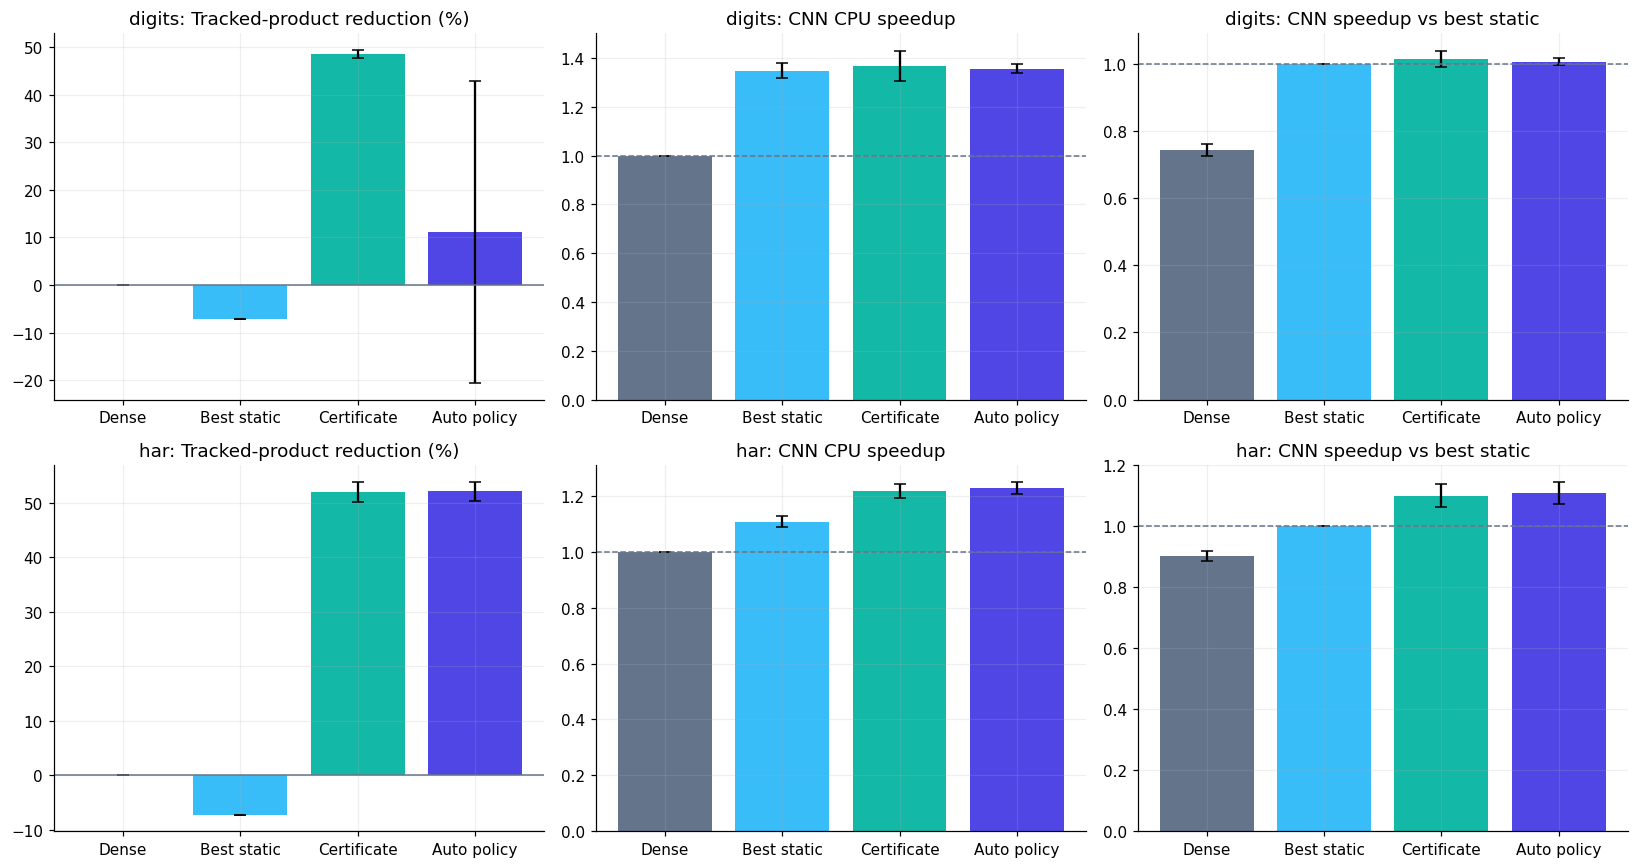

In [ ]:
#@title Comparison across three seeds
columns=['Accuracy (%)','Reference agreement (%)','Channels skipped (%)',
         'Convolution MAC reduction (%)','Tracked-product reduction (%)',
         'Block CPU speedup','CNN CPU speedup','CNN speedup vs best static']
summary=results.groupby(['Task','Method'],sort=False)[columns].agg(['mean','std'])
summary.columns=[f'{a} {b}' for a,b in summary.columns]
display(summary.reset_index().round(3))
fig,axes=plt.subplots(2,3,figsize=(15,8))
chosen=['Full INT8','Best exact static','Low-rank certificate','Auto CPU policy']
metrics=['Tracked-product reduction (%)','CNN CPU speedup','CNN speedup vs best static']
for row,task in enumerate(['digits','har']):
    for col,metric in enumerate(metrics):
        ax=axes[row,col]
        subset=results[(results.Task==task)&results.Method.isin(chosen)]
        g=subset.groupby('Method')[metric].agg(['mean','std']).reindex(chosen)
        ax.bar(np.arange(len(chosen)),g['mean'],yerr=g['std'].fillna(0),capsize=4,
               color=['#64748b','#38bdf8','#14b8a6','#4f46e5'])
        ax.set_xticks(np.arange(len(chosen)),['Dense','Best static','Certificate','Auto policy'])
        ax.set_title(f'{task}: {metric}')
        if 'speedup' in metric:ax.axhline(1,color='#64748b',linestyle='--',linewidth=1)
        else:ax.axhline(0,color='#64748b',linewidth=1)
plt.tight_layout();plt.show()

accuracy_mean  accuracy_std  \
Task   Method                                                     
digits Full INT8                           95.778         0.801   
       Exact factorized + residual         95.778         0.801   
       Approximate rank-8                  95.630         0.714   
       Best exact static                   95.778         0.801   
       Auto CPU policy                     95.778         0.801   
har    Full INT8                           88.304         1.751   
       Exact factorized + residual         88.304         1.751   
       Approximate rank-8                  88.350         1.765   
       Best exact static                   88.304         1.751   
       Auto CPU policy                     88.304         1.751   

                                    agreement_mean  disagreements  \
Task   Method                                                       
digits Full INT8                           100.000              0   
       Exact factorized + residual         100.000              0   
       Approximate rank-8                   99.852              2   
       Best exact static                   100.000              0   
       Auto CPU policy                     100.000              0   
har    Full INT8                           100.000              0   
       Exact factorized + residual         100.000              0   
       Approximate rank-8                   99.548             40   
       Best exact static                   100.000              0   
       Auto CPU policy                     100.000              0   

                                    cpu_speedup_mean  cpu_speedup_std  
Task   Method                                                          
digits Full INT8                               1.000            0.000  
       Exact factorized + residual             1.147            0.042  
       Approximate rank-8                      1.617            0.047  
       Best exact static                       1.348            0.031  
       Auto CPU policy                         1.356            0.018  
har    Full INT8                               1.000            0.000  
       Exact factorized + residual             0.905            0.019  
       Approximate rank-8                      1.360            0.021  
       Best exact static                       1.108            0.020  
       Auto CPU policy                         1.227            0.021

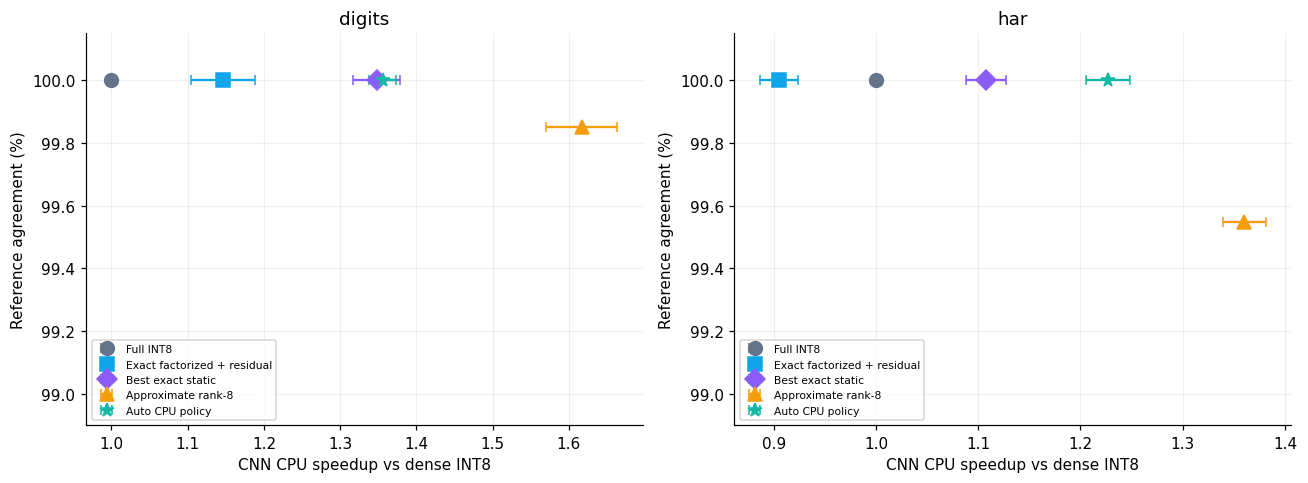

In [ ]:
#@title Exact and approximate baseline comparisons
# Approximate inference has no decision-equivalence guarantee.
baselines=['Full INT8','Exact factorized + residual','Best exact static',
           'Approximate rank-8','Auto CPU policy']
comparison=results[results.Method.isin(baselines)].groupby(['Task','Method'],sort=False).agg(
    accuracy_mean=('Accuracy (%)','mean'),accuracy_std=('Accuracy (%)','std'),
    agreement_mean=('Reference agreement (%)','mean'),
    disagreements=('Reference disagreements','sum'),
    cpu_speedup_mean=('CNN CPU speedup','mean'),cpu_speedup_std=('CNN CPU speedup','std'))
display(comparison.round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
colors=['#64748b','#0ea5e9','#8b5cf6','#f59e0b','#14b8a6']
for ax,task in zip(axes,['digits','har']):
    for name,color,marker in zip(baselines,colors,['o','s','D','^','*']):
        g=results[(results.Task==task)&(results.Method==name)]
        ax.errorbar(g['CNN CPU speedup'].mean(),g['Reference agreement (%)'].mean(),
            xerr=g['CNN CPU speedup'].std(),fmt=marker,color=color,
            markersize=9,capsize=3,label=name)
    ax.set(title=task,xlabel='CNN CPU speedup vs dense INT8',
           ylabel='Reference agreement (%)',ylim=(98.9,100.15))
    ax.legend(fontsize=7,loc='lower left')
plt.tight_layout();plt.show()

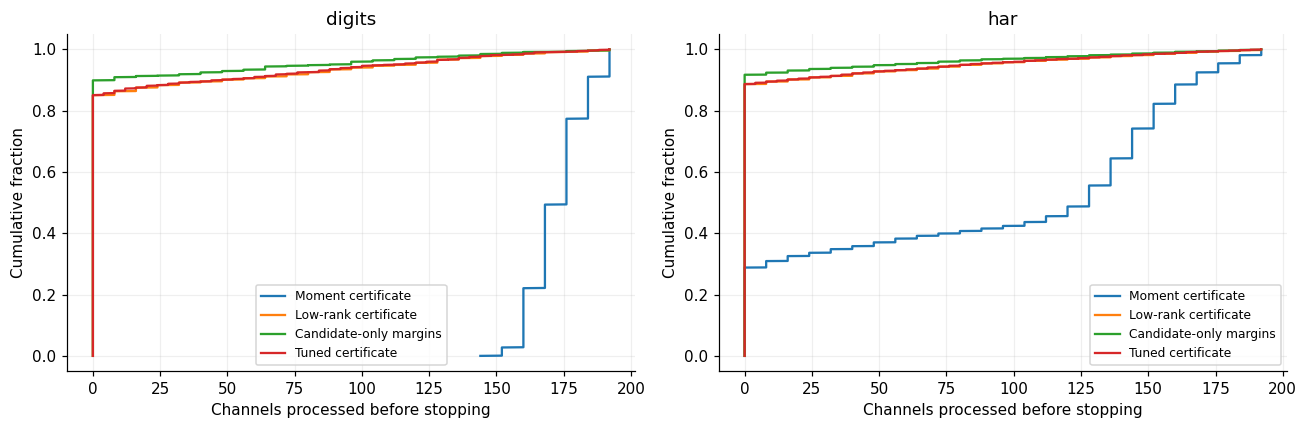

,Task,Method,Median channels,P99 channels,Maximum channels,Median tracked products,P99 tracked products,Maximum tracked products
0,digits,Full INT8,192.0,192.0,192,400896.0,400896.00,400896
1,digits,Low-rank certificate,0.0,168.0,192,179200.0,542368.64,595456
2,digits,Tuned certificate,0.0,164.0,192,179200.0,533989.12,586784
3,digits,Auto CPU policy,192.0,192.0,192,429568.0,486620.48,586784
4,har,Full INT8,192.0,192.0,192,397824.0,397824.00,397824
5,har,Low-rank certificate,0.0,168.0,192,173056.0,500582.40,579072
6,har,Tuned certificate,0.0,164.0,192,173056.0,497715.20,573952
7,har,Auto CPU policy,0.0,164.0,192,173056.0,497715.20,573952


In [ ]:
#@title Stopping distributions
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,task in zip(axes,['digits','har']):
    for name in ['Moment certificate','Low-rank certificate','Candidate-only margins','Tuned certificate']:
        counts=np.concatenate([raw_stats[(task,seed,name)][:,0] for seed in SEEDS])
        values=np.sort(counts)
        ax.plot(values,np.arange(1,len(values)+1)/len(values),label=name)
    ax.set(title=task,xlabel='Channels processed before stopping',ylabel='Cumulative fraction')
    ax.legend(fontsize=8)
plt.tight_layout();plt.show()
tail_rows=[]
for task in ['digits','har']:
    for name in ['Full INT8','Low-rank certificate','Tuned certificate','Auto CPU policy']:
        st=np.concatenate([raw_stats[(task,seed,name)] for seed in SEEDS])
        products=st[:,1:4].sum(1)
        tail_rows.append({'Task':task,'Method':name,'Median channels':np.median(st[:,0]),
            'P99 channels':np.percentile(st[:,0],99),'Maximum channels':int(st[:,0].max()),
            'Median tracked products':np.median(products),
            'P99 tracked products':np.percentile(products,99),
            'Maximum tracked products':int(products.max())})
display(pd.DataFrame(tail_rows).round(2))

,Task,Bound,Mean interval width,Exact activation sums (%),Bounds checked,Violations
0,digits,Static,2032.000,0.000,76800,0
1,digits,Input intervals,2031.945,0.000,76800,0
2,digits,Moments,1482.721,0.000,76800,0
3,digits,Low rank,76.965,1.626,76800,0
4,har,Static,2032.000,0.000,76800,0
5,har,Input intervals,1333.659,16.930,76800,0
6,har,Moments,762.377,16.802,76800,0
7,har,Low rank,61.434,24.062,76800,0


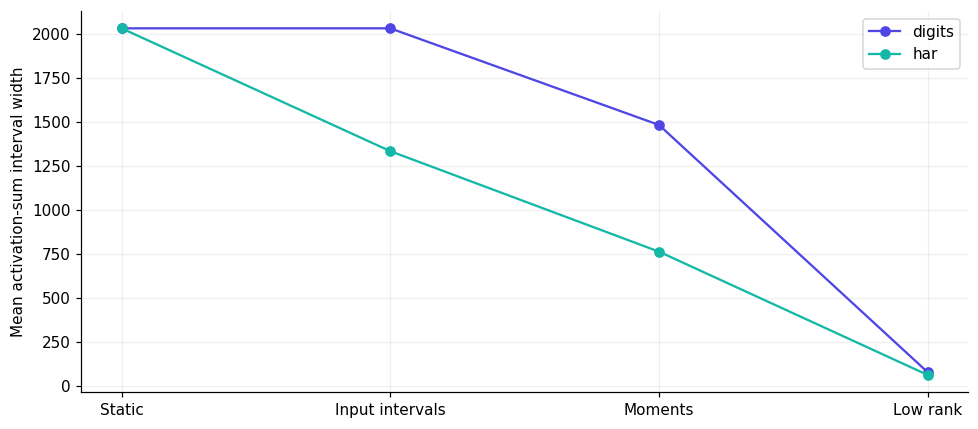

In [ ]:
#@title Bound tightness and validity
bound_rows=[]
for task in ['digits','har']:
    q=models[(task,SEEDS[0])];x=features[(task,SEEDS[0],'test')]
    idx=np.random.default_rng(561).choice(len(x),min(100,len(x)),False)
    for mode,name in [(0,'Static'),(1,'Input intervals'),(2,'Moments'),(3,'Low rank')]:
        widths=[];collapsed=0;count=0;violations=0
        for n in idx:
            lo,hi,h=bounds(lib,q,x[n],mode,rank=8)
            widths.extend((hi-lo).ravel());collapsed+=int((hi==lo).sum());count+=lo.size
            violations+=int(((h<lo)|(h>hi)).sum())
        assert violations==0
        bound_rows.append({'Task':task,'Bound':name,'Mean interval width':np.mean(widths),
            'Exact activation sums (%)':100*collapsed/count,'Bounds checked':count,'Violations':violations})
display(pd.DataFrame(bound_rows).round(3))
fig,ax=plt.subplots(figsize=(9,4))
for task,color in [('digits','#4f46e5'),('har','#14b8a6')]:
    subset=pd.DataFrame(bound_rows).query('Task==@task')
    ax.plot(subset['Bound'],subset['Mean interval width'],marker='o',label=task,color=color)
ax.set(ylabel='Mean activation-sum interval width');ax.legend()
plt.tight_layout();plt.show()

In [ ]:
#@title Perturbed-input correctness
robust_rows=[]
rng=np.random.default_rng(431)
for task in ['digits','har']:
    indices=rng.choice(len(data[f'{task}_test_x']),min(256,len(data[f'{task}_test_x'])),False)
    original=data[f'{task}_test_x'][indices]
    labels=data[f'{task}_test_y'][indices]
    for sigma in [0,2,8]:
        noisy=original.astype(np.int16)+np.rint(rng.normal(0,sigma,original.shape)).astype(np.int16)
        noisy=np.clip(noisy,0 if task=='digits' else -127,64 if task=='digits' else 127).astype(np.int8)
        for seed in SEEDS:
            q=models[(task,seed)];x=back_features(lib,q,patches(task,noisy))
            ref,_,_=full(lib,q,x);pred,stats=adaptive(lib,q,x,configs[(task,seed)])
            np.testing.assert_array_equal(pred,ref)
            robust_rows.append({'Task':task,'Seed':seed,'Noise SD (input LSB)':sigma,
                'Samples':len(x),'Reference agreement (%)':100*np.mean(pred==ref),
                'Accuracy (%)':100*accuracy_score(labels,pred),
                'Channels skipped (%)':100*(1-stats[:,0].mean()/q['w2'].shape[0])})
display(pd.DataFrame(robust_rows).round(3))
subject_rows=[]
subjects=data['har_test_subject'];labels=data['har_test_y']
for subject in np.unique(subjects):
    mask=subjects==subject
    for seed in SEEDS:
        pred=predictions[('har',seed,'Auto CPU policy')]
        ref=predictions[('har',seed,'Full INT8')]
        stats=raw_stats[('har',seed,'Auto CPU policy')][mask]
        subject_rows.append({'Subject':int(subject),'Seed':seed,'Samples':int(mask.sum()),
            'Accuracy (%)':100*np.mean(pred[mask]==labels[mask]),
            'Reference agreement (%)':100*np.mean(pred[mask]==ref[mask]),
            'Tracked products per sample':stats[:,1:4].sum(1).mean()})
subject_table=pd.DataFrame(subject_rows).groupby('Subject').agg(
    samples=('Samples','first'),accuracy_mean=('Accuracy (%)','mean'),
    accuracy_std=('Accuracy (%)','std'),reference_agreement=('Reference agreement (%)','min'),
    products_mean=('Tracked products per sample','mean'))
display(subject_table.round(3))

,Task,Seed,Noise SD (input LSB),Samples,Reference agreement (%),Accuracy (%),Channels skipped (%)
0,digits,17,0,256,100.0,94.141,92.220
1,digits,29,0,256,100.0,92.969,90.511
2,digits,43,0,256,100.0,95.312,93.278
3,digits,17,2,256,100.0,93.359,91.593
4,digits,29,2,256,100.0,93.750,90.430
5,digits,43,2,256,100.0,95.312,92.896
6,digits,17,8,256,100.0,90.625,85.758
7,digits,29,8,256,100.0,91.406,88.826
8,digits,43,8,256,100.0,90.234,86.825
9,har,17,0,256,100.0,86.328,94.670


,samples,accuracy_mean,accuracy_std,reference_agreement,products_mean
Subject,,,,,
2,302,88.411,2.710,100.0,189359.929
4,317,89.274,3.470,100.0,196296.749
9,288,72.454,3.903,100.0,213871.593
10,294,56.803,0.900,100.0,200165.007
12,320,95.000,3.684,100.0,186033.100
13,327,99.388,0.530,100.0,179253.790
18,364,96.795,2.553,100.0,186403.634
20,354,94.256,3.856,100.0,191211.992
24,381,94.926,3.896,100.0,179303.531


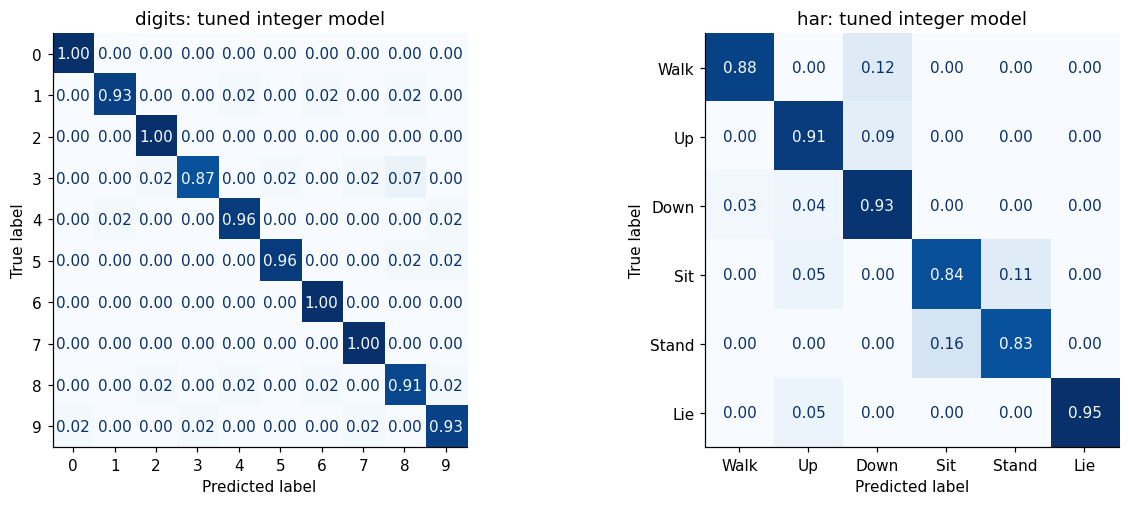

In [ ]:
#@title Confusion matrices
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
for ax,task in zip(axes,['digits','har']):
    labels=data[f'{task}_test_y'];pred=predictions[(task,SEEDS[0],'Tuned certificate')]
    names=[str(i) for i in range(10)] if task=='digits' else ['Walk','Up','Down','Sit','Stand','Lie']
    cm=confusion_matrix(labels,pred,normalize='true')
    ConfusionMatrixDisplay(cm,display_labels=names).plot(ax=ax,colorbar=False,cmap='Blues',values_format='.2f')
    ax.set_title(f'{task}: tuned integer model');ax.grid(False)
plt.tight_layout();plt.show()

In [ ]:
#@title Final results
final=results[results.Method=='Auto CPU policy'].groupby('Task').agg(
    accuracy_mean=('Accuracy (%)','mean'),accuracy_std=('Accuracy (%)','std'),
    reference_agreement=('Reference agreement (%)','min'),
    conv_mac_reduction=('Convolution MAC reduction (%)','mean'),
    tracked_product_reduction=('Tracked-product reduction (%)','mean'),
    block_cpu_speedup=('Block CPU speedup','mean'),cnn_cpu_speedup=('CNN CPU speedup','mean'),
    cnn_speedup_vs_best_static=('CNN speedup vs best static','mean'))
display(final.round(3))
print('PASS: all exact methods agree with the full integer model.')
print('Seeds:',len(SEEDS),'| tasks:',2,'| test decisions per exact method:',
      len(SEEDS)*(len(data['digits_test_y'])+len(data['har_test_y'])))
# CPU timings are measured here; microcontroller cycles and joules are not measured.

PASS: all exact methods agree with the full integer model.
Seeds: 3 | tasks: 2 | test decisions per exact method: 10191


,accuracy_mean,accuracy_std,reference_agreement,conv_mac_reduction,tracked_product_reduction,block_cpu_speedup,cnn_cpu_speedup,cnn_speedup_vs_best_static
Task,,,,,,,,
digits,95.778,0.801,100.0,30.931,11.170,1.580,1.356,1.006
har,88.304,1.751,100.0,95.692,52.076,1.336,1.227,1.108
